In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage

import pickle
import os

In [2]:
os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

print("Folders Ready")

Folders Ready


In [3]:
df = pd.read_csv("data/cleaned_customers.csv")

print(df.shape)

df.head()

(53503, 23)


,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,...,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group,Age_Group,Income_Level,Spending_Category
0,84966,23,0,1,0,22,3,70541,4,270,...,2749,2,0,1,0,0,4,3,2,2
1,95568,26,1,4,2,10,5,54168,4,942,...,1966,2,2,1,3,1,4,0,2,0
2,10544,29,0,3,0,27,3,73899,4,387,...,4413,2,0,2,2,2,2,0,2,0
3,77033,20,1,0,1,28,3,63381,4,582,...,4342,1,4,1,1,1,2,3,2,0
4,88160,25,0,2,1,34,5,38794,0,630,...,1276,1,0,4,4,0,1,3,1,2


In [4]:
features = [
    "Age",
    "Income Level",
    "Coverage Amount",
    "Premium Amount"
]

X = df[features]

X.head()

,Age,Income Level,Coverage Amount,Premium Amount
0,23,70541,366603,2749
1,26,54168,780236,1966
2,29,73899,773926,4413
3,20,63381,787815,4342
4,25,38794,366506,1276


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(53503, 4)


In [6]:
sample_df = df.sample(
    n=1000,
    random_state=42
)

sample_X = sample_df[features]

sample_scaled = scaler.fit_transform(
    sample_X
)

print(sample_scaled.shape)

(1000, 4)


In [7]:
linked = linkage(
    sample_scaled,
    method="ward"
)

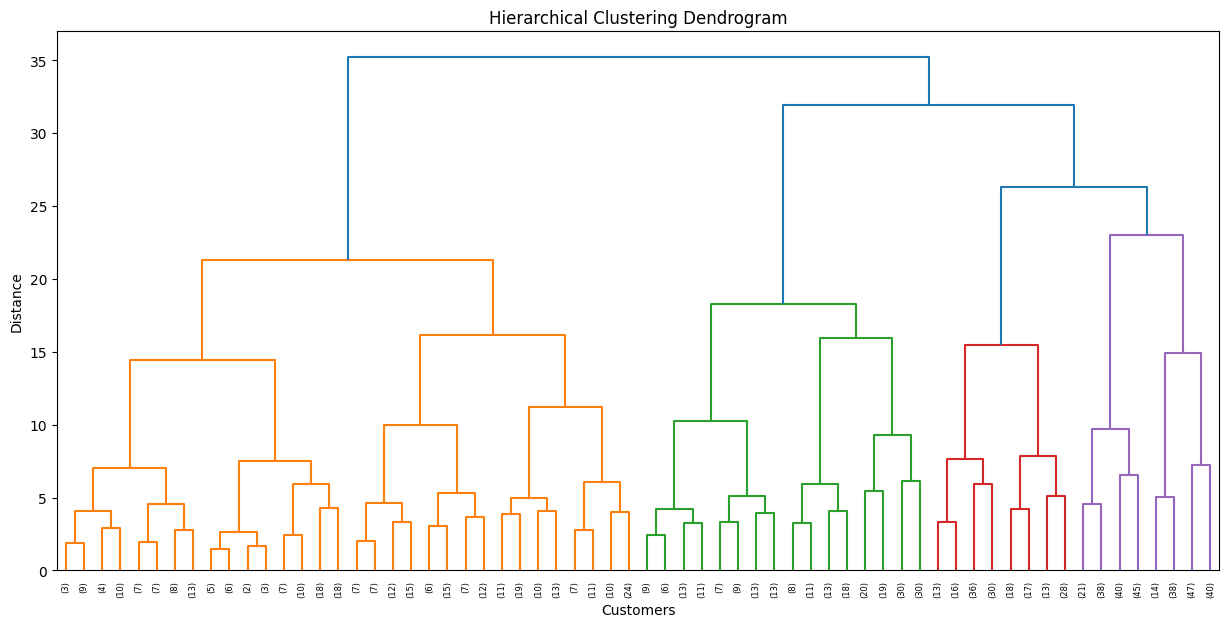

In [8]:
plt.figure(figsize=(15,7))

dendrogram(
    linked,
    truncate_mode="level",
    p=5
)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

In [9]:
#The dendrogram helps identify the number of natural customer groups.

#A cut around 5 clusters provides meaningful segmentation.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.decomposition import PCA

import pickle
import os

In [3]:
print(AgglomerativeClustering)

<class 'sklearn.cluster._agglomerative.AgglomerativeClustering'>


In [4]:
# Load data
df = pd.read_csv("data/cleaned_customers.csv")

features = [
    "Age",
    "Income Level",
    "Coverage Amount",
    "Premium Amount"
]

X = df[features]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [2]:
from sklearn.cluster import AgglomerativeClustering

print("Import Successful")

Import Successful


In [4]:
import pandas as pd

df = pd.read_csv("data/cleaned_customers.csv")

print(df.shape)
df.head()

(53503, 23)


,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,...,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group,Age_Group,Income_Level,Spending_Category
0,84966,23,0,1,0,22,3,70541,4,270,...,2749,2,0,1,0,0,4,3,2,2
1,95568,26,1,4,2,10,5,54168,4,942,...,1966,2,2,1,3,1,4,0,2,0
2,10544,29,0,3,0,27,3,73899,4,387,...,4413,2,0,2,2,2,2,0,2,0
3,77033,20,1,0,1,28,3,63381,4,582,...,4342,1,4,1,1,1,2,3,2,0
4,88160,25,0,2,1,34,5,38794,0,630,...,1276,1,0,4,4,0,1,3,1,2


In [5]:
features = [
    "Age",
    "Income Level",
    "Coverage Amount",
    "Premium Amount"
]

X = df[features]

X.head()

,Age,Income Level,Coverage Amount,Premium Amount
0,23,70541,366603,2749
1,26,54168,780236,1966
2,29,73899,773926,4413
3,20,63381,787815,4342
4,25,38794,366506,1276


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(53503, 4)


In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

In [3]:
df = pd.read_csv("data/cleaned_customers.csv")

print(df.shape)

(53503, 23)


In [4]:
sample_df = df.sample(
    n=5000,
    random_state=42
)

print(sample_df.shape)

(5000, 23)


In [5]:
features = [
    "Age",
    "Income Level",
    "Coverage Amount",
    "Premium Amount"
]

sample_X = sample_df[features]

In [6]:
scaler = StandardScaler()

sample_scaled = scaler.fit_transform(sample_X)

print(sample_scaled.shape)

(5000, 4)


In [7]:
hierarchical = AgglomerativeClustering(
    n_clusters=5
)

clusters = hierarchical.fit_predict(
    sample_scaled
)

sample_df["Hierarchical_Cluster"] = clusters

print("Hierarchical Clustering Completed")

Hierarchical Clustering Completed


In [8]:
hierarchical_profile = sample_df.groupby(
    "Hierarchical_Cluster"
)[
    [
        "Age",
        "Income Level",
        "Coverage Amount",
        "Premium Amount"
    ]
].mean()

hierarchical_profile.round(2)

,Age,Income Level,Coverage Amount,Premium Amount
Hierarchical_Cluster,,,,
0,32.95,79784.10,384410.08,3915.20
1,42.51,115313.33,723281.43,2793.50
2,42.95,57764.12,502509.28,1587.24
3,55.26,53422.15,516344.86,3870.03
4,58.64,119874.20,303928.68,2907.64


In [9]:
print(df.shape)

(53503, 23)
